### Basic Libraries and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic visual configuration
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)

### Mapping and Loading Raw Files

In [2]:
# Path to the raw data folder 
RAW_PATH = "../data/raw"

# Loading calendar and prices
print("Loading calendar.csv...")
calendar = pd.read_csv(f'{RAW_PATH}/calendar.csv')

print("Loading sell_prices.csv...")
prices = pd.read_csv(f'{RAW_PATH}/sell_prices.csv')

# Loading sales (with a 10,000 row limit to avoid RAM issues)
print("Loading sales_train_evaluation.csv...")
sales = pd.read_csv(f'{RAW_PATH}/sales_train_evaluation.csv', nrows=10000)

print("Data loaded successfully!")

Loading calendar.csv...
Loading sell_prices.csv...
Loading sales_train_evaluation.csv...
Data loaded successfully!


### Calendar Inspection

In [6]:
# Checking calendar data
display(calendar.head(100))
calendar.info()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2011-05-04,11114,Wednesday,5,5,2011,d_96,NaN,NaN,NaN,NaN,1,0,0
96,2011-05-05,11114,Thursday,6,5,2011,d_97,Cinco De Mayo,Cultural,NaN,NaN,1,1,1
97,2011-05-06,11114,Friday,7,5,2011,d_98,NaN,NaN,NaN,NaN,1,1,1
98,2011-05-07,11115,Saturday,1,5,2011,d_99,NaN,NaN,NaN,NaN,1,1,0


<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [7]:
# Checking days with events (SNAP, Holidays)
print("\nEvents detected in event_type_1:")
print(calendar['event_type_1'].value_counts(dropna=False))


Events detected in event_type_1:
event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18
Name: count, dtype: int64


### Prices Inspection

In [10]:
# Checking prices data
display(prices.head(10))
prices.info()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
5,CA_1,HOBBIES_1_001,11330,8.26
6,CA_1,HOBBIES_1_001,11331,8.26
7,CA_1,HOBBIES_1_001,11332,8.26
8,CA_1,HOBBIES_1_001,11333,8.26
9,CA_1,HOBBIES_1_001,11334,8.26


<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 208.8 MB


In [11]:
# Checking descriptive statistics for prices
print("\nDescriptive statistics for sell_price:")
display(prices['sell_price'].describe())


Descriptive statistics for sell_price:


count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

### Sales Inspection (Horizontal Format)

In [12]:
# Here you will see the columns d_1, d_2, d_3... 
display(sales.head(10))
sales.info()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,...,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,2,0,3,5,0,0,1,1,0,2,1,2,2,1,0,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,2,1,0,0,0,0,2,1,3,0,0,1,0,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,2,4,1,6,4,0,0,0,2,2,4,2,1,1,1,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,3,1,0,3,2,3,1,1,3,2,3,2,2,2,2,0,0,0,2,1,0,0,2,1,0
5,HOBBIES_1_006_CA_1_evaluation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,2,4,1,0,0,0,2,1,0,0,3,0,5,2,1,0,0,1,0,0,5,2,0
6,HOBBIES_1_007_CA_1_evaluation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0
7,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,12,15,0,0,0,4,6,5,7,0,13,2,2,20,9,3,0,1,0,...,8,8,23,26,9,4,8,5,8,5,0,3,1,18,47,7,0,6,0,15,5,4,1,40,32
8,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,2,0,7,3,0,2,3,9,0,0,4,3,1,0,4,4,1,2,0,...,0,0,0,0,0,0,0,8,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
9,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,2,...,0,0,0,0,0,0,0,0,2,0,2,1,0,0,1,0,0,1,0,2,1,1,0,0,1


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 148.5 MB


In [13]:
# Checking the hierarchies present in the raw dataset
print("\nUnique stores:", sales['store_id'].unique())
print("Unique categories:", sales['cat_id'].unique())
print("Unique departments:", sales['dept_id'].unique())


Unique stores: <StringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4']
Length: 4, dtype: str
Unique categories: <StringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str
Unique departments: <StringArray>
[  'HOBBIES_1',   'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2',     'FOODS_1',
     'FOODS_2',     'FOODS_3']
Length: 7, dtype: str


### Raw Time Series Visualization

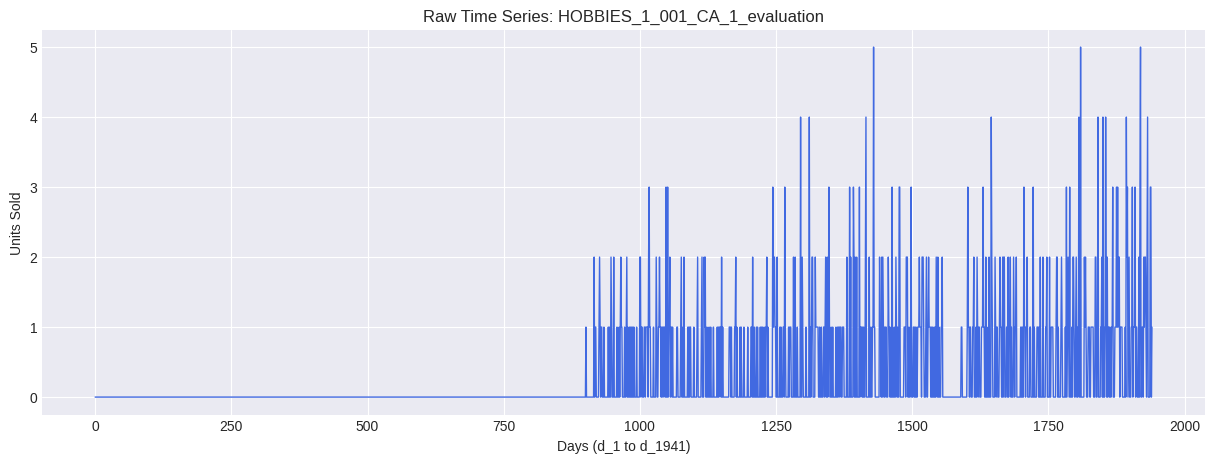

In [14]:
# Selecting the first product from the raw dataset (e.g., HOBBIES_1_001_CA_1)
sample_product = sales.iloc[0]

# Extracting only the day columns (d_1 to d_1941)
day_cols = [col for col in sales.columns if col.startswith('d_')]
sales_series = sample_product[day_cols].values.astype(float)

# Plotting the raw series, without any preprocessing
plt.figure(figsize=(15, 5))
plt.plot(sales_series, color='royalblue', linewidth=1)
plt.title(f"Raw Time Series: {sample_product['id']}")
plt.xlabel("Days (d_1 to d_1941)")
plt.ylabel("Units Sold")
plt.show()